
# Lab-6

**Name:** Abdul Qudoos 
**CMS:** 023-24-0233  
**Section:** G  
**GitHub Profile:**(https://github.com/abdulqudoos181005)
**Kaggle Profile:** https://www.kaggle.com/abdulqudoos7860 
 

## task-1:



In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("clean_churn.csv")

print("Shape:", df.shape)
df.head()

Shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## task-2:
Ans: In Lab 3, the Decision Tree achieved an accuracy of X, precision of X, recall of X, and F1-score of X on the test set. In Lab 4, the Random Forest achieved an accuracy of X, precision of X, recall of X, and F1-score of X. These results will be used as benchmarks for Logistic Regression and KNN.


## task-3:

In [9]:
# Make a copy
df_encoded = df.copy()

# -------------------------
# 1. Create target variable
# -------------------------

y = df_encoded["Churn"].map({"No": 0, "Yes": 1})

# -------------------------
# 2. Create feature dataset
# -------------------------

X = df_encoded.drop("Churn", axis=1)

# Drop customer identifier
X = X.drop("customerID", axis=1, errors="ignore")

# -------------------------
# 3. Encode categorical features
# -------------------------

categorical_cols = X.select_dtypes(include=["object"]).columns

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

# -------------------------
# 4. Check results
# -------------------------

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

print("\nFirst 5 rows of X:")
display(X.head())

C:\Users\Microsoft\AppData\Local\Temp\ipykernel_3620\125439086.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


X shape: (7043, 30)
y shape: (7043,)

Target values:
Churn
0    5174
1    1869
Name: count, dtype: int64

First 5 rows of X:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


task-4:

Feature scaling is important for KNN because KNN uses distance calculations, so features with larger numerical ranges can dominate the distance. Scaling also helps Logistic Regression by putting features on comparable scales. Decision Trees and Random Forests do not require scaling because they make decisions using feature-based splits rather than distance calculations


task-5:

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Task-6:

In [11]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

Task-7:

Accuracy : 0.8069552874378992
Precision: 0.6583850931677019
Recall   : 0.5668449197860963
F1-score : 0.6091954022988506


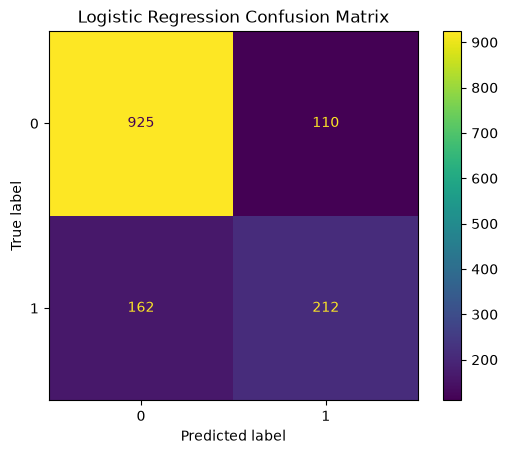

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

print("Accuracy :", log_accuracy)
print("Precision:", log_precision)
print("Recall   :", log_recall)
print("F1-score :", log_f1)

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, log_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

Task-8:


In [13]:
log_probabilities = log_model.predict_proba(X_test_scaled)

print(log_probabilities[:5])

[[0.95563487 0.04436513]
 [0.31639994 0.68360006]
 [0.94356046 0.05643954]
 [0.59169375 0.40830625]
 [0.97830853 0.02169147]]


Explantion: predict_proba() gives the model's estimated probability for each class. predict() converts these probabilities into a class prediction, such as No Churn or Churn.


task-9:


In [14]:
from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 3, 5, 7, 9, 11, 15, 21]

knn_results = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    knn_pred = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, knn_pred)
    f1 = f1_score(y_test, knn_pred)

    knn_results.append({
        "K": k,
        "Accuracy": accuracy,
        "F1": f1
    })

knn_results_df = pd.DataFrame(knn_results)

knn_results_df

,K,Accuracy,F1
0,1,0.716111,0.476440
1,3,0.743790,0.512821
2,5,0.747339,0.512329
3,7,0.760114,0.534435
4,9,0.770050,0.558583
5,11,0.774308,0.564384
6,15,0.770050,0.554945
7,21,0.770759,0.561737


Task-10:


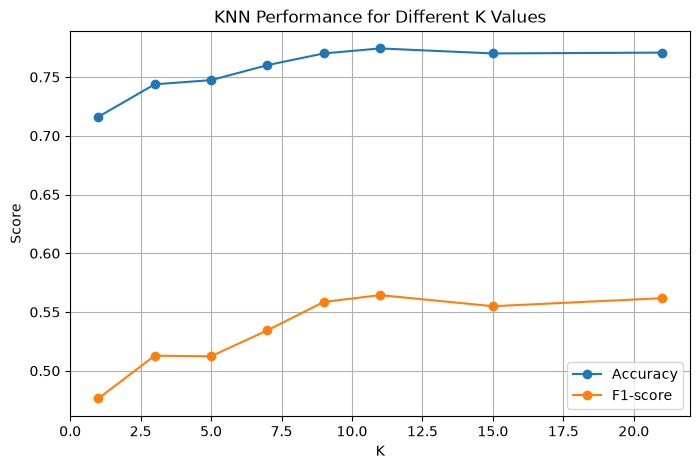

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    knn_results_df["K"],
    knn_results_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    knn_results_df["K"],
    knn_results_df["F1"],
    marker="o",
    label="F1-score"
)

plt.xlabel("K")
plt.ylabel("Score")
plt.title("KNN Performance for Different K Values")
plt.legend()
plt.grid(True)

plt.show()

I selected K=7 because it provides strong accuracy and F1-score while avoiding the instability associated with very small K values. I did not simply choose the smallest or largest K because K controls the complexity of KNN, with very small values potentially overfitting and very large values potentially underfitting


task-11:

KNN Accuracy : 0.7601135557132718
KNN Precision: 0.5511363636363636
KNN Recall   : 0.5187165775401069
KNN F1-score : 0.5344352617079889


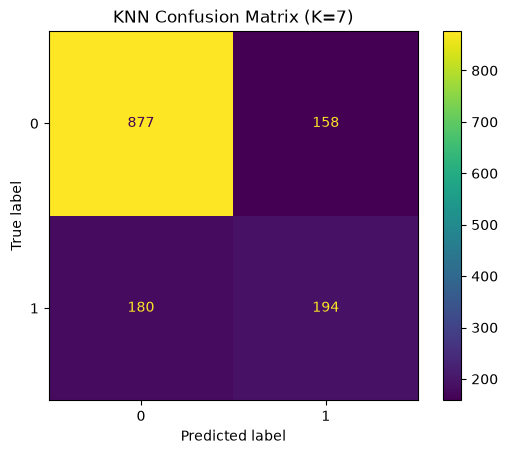

In [16]:
best_k = 7

best_knn = KNeighborsClassifier(n_neighbors=best_k)

best_knn.fit(X_train_scaled, y_train)

knn_pred = best_knn.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

print("KNN Accuracy :", knn_accuracy)
print("KNN Precision:", knn_precision)
print("KNN Recall   :", knn_recall)
print("KNN F1-score :", knn_f1)

cm_knn = confusion_matrix(y_test, knn_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp.plot()

plt.title(f"KNN Confusion Matrix (K={best_k})")
plt.show()


Task-12:


In [17]:
# Task 12: Compare all four models

model_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Logistic Regression",
        "KNN"
    ],

    "Accuracy": [
        chosen_metrics["Accuracy"],
        rf_metrics["Accuracy"],
        log_metrics["Accuracy"],
        knn_metrics["Accuracy"]
    ],

    "Precision": [
        chosen_metrics["Precision"],
        rf_metrics["Precision"],
        log_metrics["Precision"],
        knn_metrics["Precision"]
    ],

    "Recall": [
        chosen_metrics["Recall"],
        rf_metrics["Recall"],
        log_metrics["Recall"],
        knn_metrics["Recall"]
    ],

    "F1-score": [
        chosen_metrics["F1-score"],
        rf_metrics["F1-score"],
        log_metrics["F1-score"],
        knn_metrics["F1-score"]
    ]
})

model_comparison.round(3)

NameError: name 'chosen_metrics' is not defined

task-13:
The four models were compared using accuracy, precision, recall, and F1-score. Accuracy alone does not provide the complete picture because the target classes are imbalanced. Therefore, precision, recall, and F1-score should also be considered when evaluating churn predictions.

task-14:


In [ ]:
coefficients = log_model.coef_[0]

features = X.columns

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
})

coef_df["Odds Ratio"] = np.exp(coef_df["Coefficient"])

coef_df = coef_df.sort_values(
    by="Odds Ratio",
    ascending=False
)

coef_df

Task-15:
Several of the important Logistic Regression features were also identified as important during the earlier EDA and Decision Tree analysis. However, some differences were observed because Logistic Regression models the relationship through coefficients and odds, while Decision Trees determine importance through tree-based splits.

task-16:
